In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
shutil.unpack_archive("/content/drive/MyDrive/AIML_Capstone/Datasets/Capstone 1/Part 1/Images.zip")

In [3]:
images_dir='/content/Images'

In [4]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
# Load the labels from labels.csv
labels_df = pd.read_csv('/content/drive/MyDrive/AIML_Capstone/Datasets/Capstone 1/Part 1/labels.csv', sep=',', header=None)
labels_df.columns = ['image_id', 'class', 'x_min', 'y_min', 'x_max', 'y_max']

In [6]:
labels_df

,image_id,class,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45
...,...,...,...,...,...,...
351544,110590,car,18,57,97,98
351545,110591,articulated_truck,2,71,690,351
351546,110592,pickup_truck,3,240,214,378
351547,110592,car,465,111,507,135


In [7]:
# Adjust the image IDs in the dataframe
labels_df['image_id'] = labels_df['image_id'].apply(lambda x: f"{x:08d}")

In [8]:
labels_df.head()


,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45


In [9]:
# Use iloc to pick the first 1000 labels
labels_df = labels_df.iloc[:1000]
labels_df

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
...,...,...,...,...,...,...
995,00000306,motorized_vehicle,36,44,55,56
996,00000306,car,110,93,208,140
997,00000306,articulated_truck,55,19,111,37
998,00000307,car,2,233,17,283


# Images data pre processing

In [10]:
images_dir = 'Images/'
images = []
target_size = (224, 224)  # Adjust this size according to your model's requirements.

for index, row in labels_df.iterrows():
    img_path = os.path.join(images_dir, f"{row['image_id']}.jpg")
    img = cv2.imread(img_path)
    if img is not None:
        if len(img.shape) == 2:  # If grayscale, convert to RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = cv2.resize(img, target_size)  # Resize image
        images.append(img)
    else:
        print(f"Error loading image: {img_path}")

images = np.array(images)  # Convert list of images to a NumPy array

if len(images) == 0:
    print("No images loaded. Please check the image paths.")
else:
    print(f"{len(images)} images loaded successfully.")

1000 images loaded successfully.


In [11]:
len(images)

1000

In [12]:
images[0].shape

(224, 224, 3)

In [13]:
# Analyze the distribution of vehicle types in the limited dataset
vehicle_types = labels_df['class'].value_counts()
print("Distribution of vehicle types:")
print(vehicle_types)

Distribution of vehicle types:
class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [14]:
# Address data quality issues arising from the discrepancy between labels and actual image filenames
# Sorting the image filenames
labels_df = labels_df.sort_values('image_id')

In [15]:
if len(images) > 0:
    processed_images = [cv2.resize(img, (224, 224)) for img in images]  # Adjust dimensions as needed
    processed_images = np.array(processed_images)
    print("Images resized successfully.")

Images resized successfully.


In [16]:
labels = labels_df['class'].to_numpy()
bounding_boxes = labels_df[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()

In [17]:
# Convert labels to one-hot encoding
unique_labels = np.unique(labels)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
index_to_label = {index: label for index, label in enumerate(unique_labels)}
labels = np.array([label_to_index[label] for label in labels])

In [ ]:
labels

# model building

In [20]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

In [21]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("bbox_train shape:", bbox_train.shape)

print("First few y_train labels:", y_train[:5])
print("First few bbox_train labels:", bbox_train[:5])

X_train shape: (800, 224, 224, 3)
y_train shape: (800,)
bbox_train shape: (800, 4)
First few y_train labels: [3 3 3 8 3]
First few bbox_train labels: [[591  95 637 115]
 [573 219 675 285]
 [295 121 345 142]
 [324 110 381 128]
 [362 200 475 246]]


In [23]:
def create_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    vehicle_class = layers.Dense(num_classes, activation='softmax', name='vehicle_class')(x)
    bounding_box = layers.Dense(4, name='bounding_box')(x)

    model = keras.Model(inputs=inputs, outputs=[vehicle_class, bounding_box])
    return model

In [24]:
input_shape = processed_images[0].shape
num_classes = len(unique_labels)
model = create_model(input_shape, num_classes)

In [25]:
model.compile(optimizer='adam',
              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},
              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})

In [26]:
model.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=50, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - bounding_box_loss: 317510.3750 - bounding_box_mae: 247.3394 - loss: 318036.2500 - vehicle_class_accuracy: 0.0262 - vehicle_class_loss: 525.9009 - val_bounding_box_loss: 27627.9551 - val_bounding_box_mae: 131.3654 - val_loss: 27759.0371 - val_vehicle_class_accuracy: 0.0550 - val_vehicle_class_loss: 512.7294
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - bounding_box_loss: 24591.8848 - bounding_box_mae: 121.9548 - loss: 24915.6328 - vehicle_class_accuracy: 0.0625 - vehicle_class_loss: 323.7491 - val_bounding_box_loss: 22604.0176 - val_bounding_box_mae: 116.3793 - val_loss: 22298.2676 - val_vehicle_class_accuracy: 0.0150 - val_vehicle_class_loss: 203.9317
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - bounding_box_loss: 20939.6309 - bounding_box_mae: 111.0064 - loss: 21068.1582 - vehicle_class_accuracy: 0.0750 - vehicle_class_loss: 128.5266 - val_bounding_box_loss: 20785.5977 - val_bounding_box_mae: 108.4182 - val_loss: 20

In [27]:
test_results = model.evaluate(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}, verbose=2)
print('\nTest results:', test_results)

7/7 - 0s - 27ms/step - bounding_box_loss: 24220.9961 - bounding_box_mae: 112.6877 - loss: 23705.2070 - vehicle_class_accuracy: 0.6050 - vehicle_class_loss: 5.8812

Test results: [23705.20703125, 5.881155490875244, 24220.99609375, 112.6877212524414, 0.6050000190734863]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


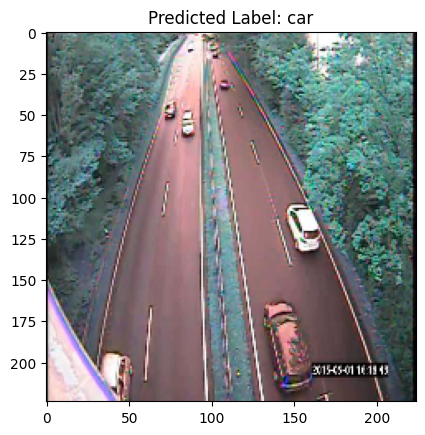

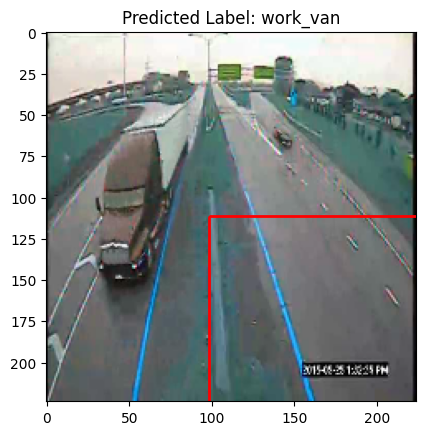

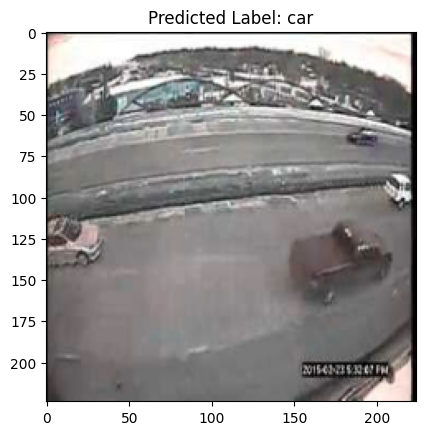

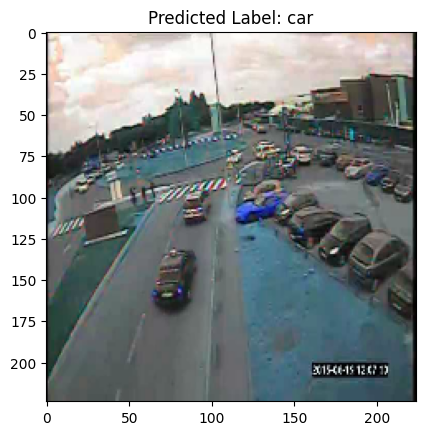

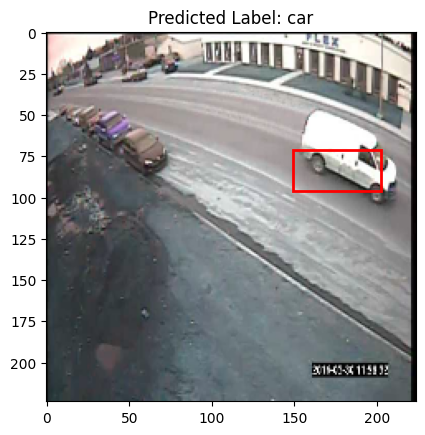

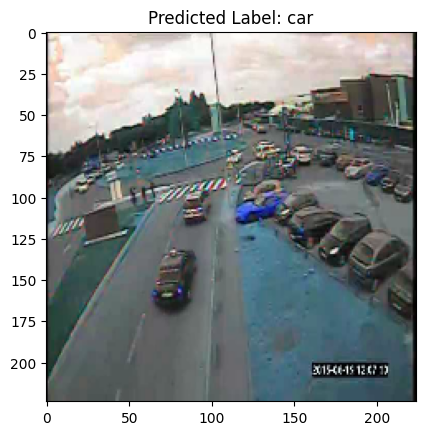

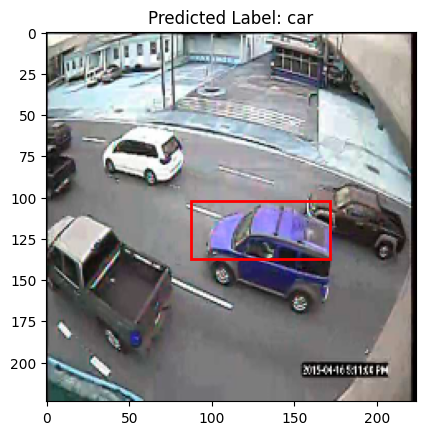

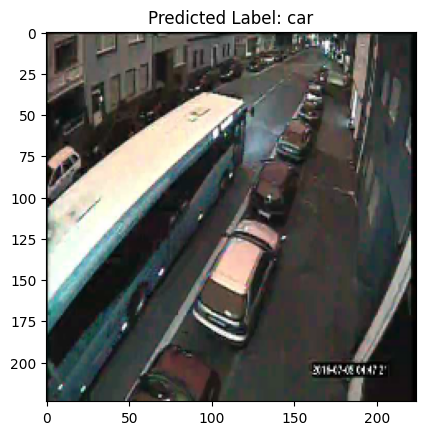

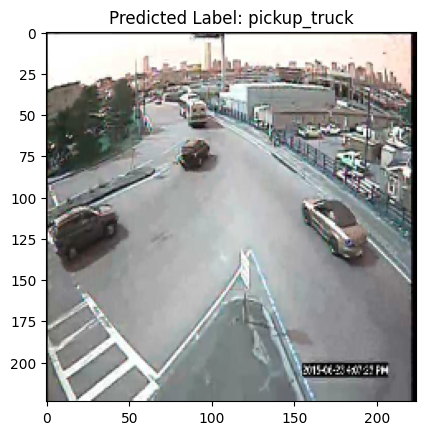

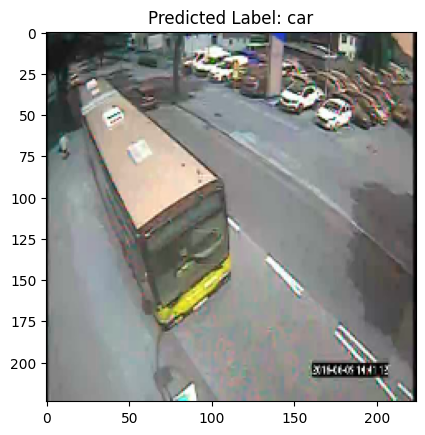

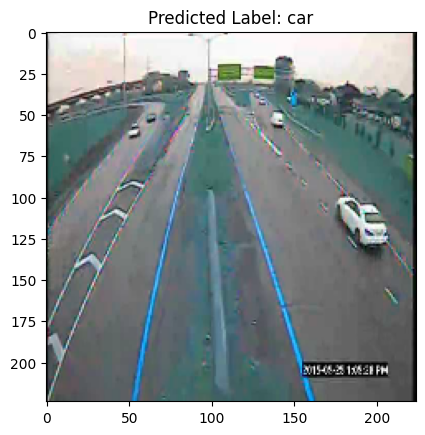

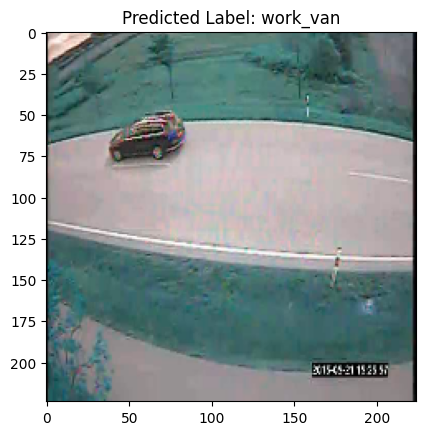

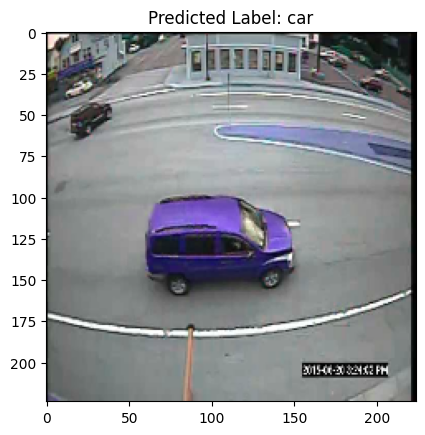

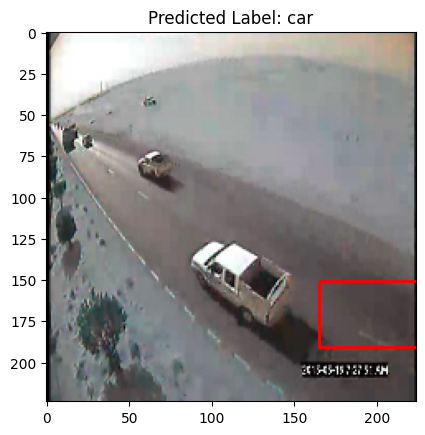

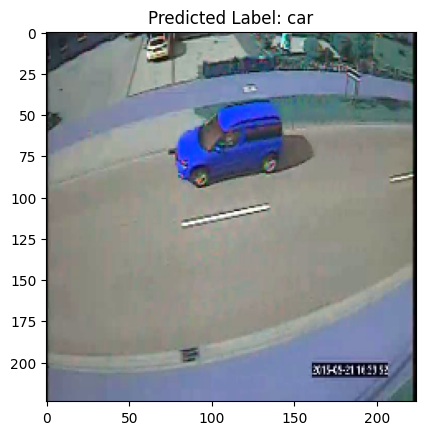

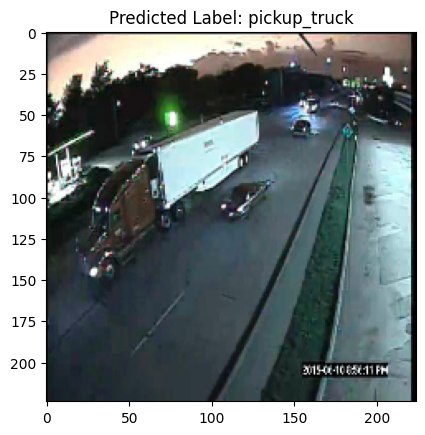

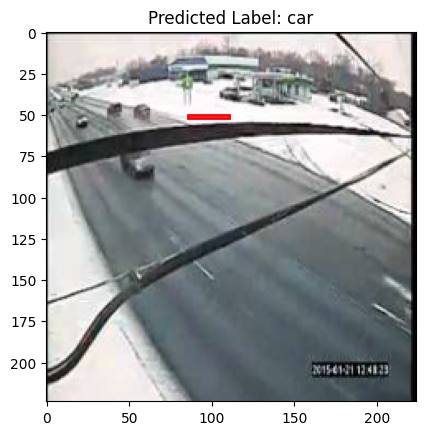

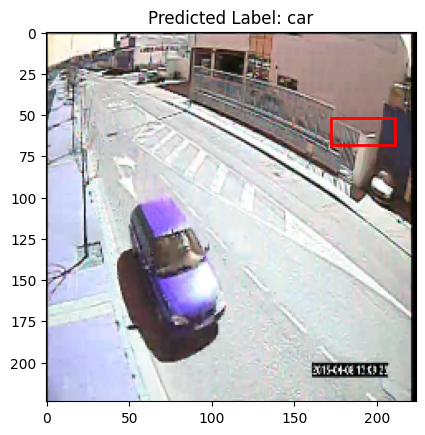

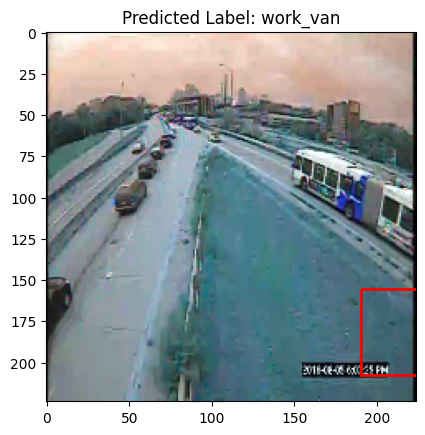

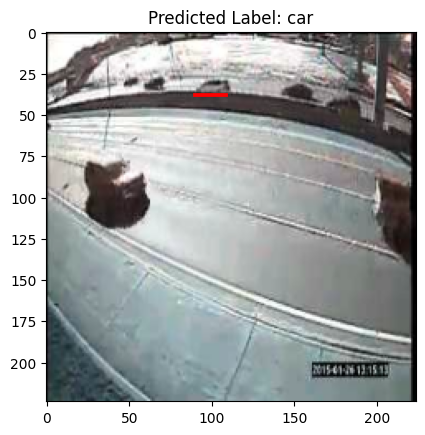

In [28]:
import matplotlib.pyplot as plt

# Choose a few sample images for inference
sample_images = X_test[:20]  # Adjust the number of sample images as needed

# Perform inference on the sample images
predictions = model.predict(sample_images)

# Extract the predicted bounding box coordinates
predicted_bounding_boxes = predictions[1]
# add labels also in for loop
# Extract the predicted labels

predicted_labels = [index_to_label[label] for label in np.argmax(predictions[0], axis=1)]

# Visualize the sample images with predicted bounding boxes
for i in range(len(sample_images)):
    plt.figure()
    plt.imshow(sample_images[i])
    # add labels also
    plt.title(f"Predicted Label: {predicted_labels[i]}")
    plt.gca().add_patch(plt.Rectangle((predicted_bounding_boxes[i][0], predicted_bounding_boxes[i][1]),
                                     predicted_bounding_boxes[i][2] - predicted_bounding_boxes[i][0],
                                     predicted_bounding_boxes[i][3] - predicted_bounding_boxes[i][1],
                                     fill=False, edgecolor='r', linewidth=2))
    plt.show()